In [2]:
# ============================================================
# CHECK fact_user_events:
# How many rows have surface NOT IN ('ad_view', 'adview')
# ============================================================

import os
import sys
import subprocess
import pandas as pd

# ============================================================
# 0. CONFIG
# ============================================================

EVENTS_PATH = "/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-2/fact_user_events"
OUTPUT_DIR = "/kaggle/working/surface_check_fact_user_events"

os.makedirs(OUTPUT_DIR, exist_ok=True)

DUCKDB_MEMORY_LIMIT = "4GB"
DUCKDB_THREADS = 4

print("EVENTS_PATH exists:", os.path.exists(EVENTS_PATH), EVENTS_PATH)

# ============================================================
# 1. SETUP DUCKDB
# ============================================================

try:
    import duckdb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "duckdb"])
    import duckdb

duckdb_path = os.path.join(OUTPUT_DIR, "surface_check.duckdb")

if os.path.exists(duckdb_path):
    os.remove(duckdb_path)

con = duckdb.connect(duckdb_path)
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")

EVENTS_GLOB = os.path.join(EVENTS_PATH, "*.parquet").replace("\\", "/")

# ============================================================
# 2. OVERALL SUMMARY
# ============================================================

overall_query = f"""
WITH base AS (
    SELECT
        CASE
            WHEN surface IS NULL THEN NULL
            ELSE LOWER(TRIM(CAST(surface AS VARCHAR)))
        END AS surface_clean
    FROM read_parquet('{EVENTS_GLOB}')
)

SELECT
    COUNT(*) AS total_rows,

    SUM(
        CASE
            WHEN surface_clean IN ('ad_view', 'adview')
            THEN 1 ELSE 0
        END
    ) AS rows_surface_ad_view_or_adview,

    SUM(
        CASE
            WHEN surface_clean IS NOT NULL
                 AND surface_clean NOT IN ('ad_view', 'adview')
            THEN 1 ELSE 0
        END
    ) AS rows_surface_not_ad_view_or_adview_exclude_null,

    SUM(
        CASE
            WHEN surface_clean IS NULL
            THEN 1 ELSE 0
        END
    ) AS rows_surface_null,

    SUM(
        CASE
            WHEN surface_clean IS NULL
                 OR surface_clean NOT IN ('ad_view', 'adview')
            THEN 1 ELSE 0
        END
    ) AS rows_surface_not_ad_view_or_adview_include_null,

    SUM(
        CASE
            WHEN surface_clean IS NOT NULL
                 AND surface_clean NOT IN ('ad_view', 'adview')
            THEN 1 ELSE 0
        END
    ) * 1.0 / NULLIF(COUNT(*), 0) AS rate_not_ad_view_exclude_null,

    SUM(
        CASE
            WHEN surface_clean IS NULL
                 OR surface_clean NOT IN ('ad_view', 'adview')
            THEN 1 ELSE 0
        END
    ) * 1.0 / NULLIF(COUNT(*), 0) AS rate_not_ad_view_include_null

FROM base
"""

overall_df = con.execute(overall_query).df()

display(overall_df)

overall_csv = os.path.join(OUTPUT_DIR, "01_surface_overall_summary.csv")
overall_df.to_csv(overall_csv, index=False, encoding="utf-8-sig")
print("[SAVE]", overall_csv)

# ============================================================
# 3. SURFACE BREAKDOWN
# ============================================================

surface_breakdown_query = f"""
WITH base AS (
    SELECT
        CASE
            WHEN surface IS NULL THEN 'NULL_SURFACE'
            ELSE LOWER(TRIM(CAST(surface AS VARCHAR)))
        END AS surface_clean
    FROM read_parquet('{EVENTS_GLOB}')
)

SELECT
    surface_clean,
    COUNT(*) AS rows,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS row_share
FROM base
GROUP BY surface_clean
ORDER BY rows DESC
"""

surface_df = con.execute(surface_breakdown_query).df()

display(surface_df.head(50))

surface_csv = os.path.join(OUTPUT_DIR, "02_surface_breakdown.csv")
surface_df.to_csv(surface_csv, index=False, encoding="utf-8-sig")
print("[SAVE]", surface_csv)

# ============================================================
# 4. EVENT_TYPE BREAKDOWN AMONG NON-AD_VIEW SURFACE
# ============================================================

event_type_non_ad_query = f"""
WITH base AS (
    SELECT
        CASE
            WHEN surface IS NULL THEN NULL
            ELSE LOWER(TRIM(CAST(surface AS VARCHAR)))
        END AS surface_clean,

        CASE
            WHEN event_type IS NULL THEN 'NULL_EVENT_TYPE'
            ELSE LOWER(TRIM(CAST(event_type AS VARCHAR)))
        END AS event_type_clean
    FROM read_parquet('{EVENTS_GLOB}')
)

SELECT
    event_type_clean,
    COUNT(*) AS rows,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS row_share
FROM base
WHERE
    surface_clean IS NOT NULL
    AND surface_clean NOT IN ('ad_view', 'adview')
GROUP BY event_type_clean
ORDER BY rows DESC
"""

event_type_non_ad_df = con.execute(event_type_non_ad_query).df()

display(event_type_non_ad_df)

event_type_non_ad_csv = os.path.join(OUTPUT_DIR, "03_event_type_breakdown_surface_not_ad_view.csv")
event_type_non_ad_df.to_csv(event_type_non_ad_csv, index=False, encoding="utf-8-sig")
print("[SAVE]", event_type_non_ad_csv)

# ============================================================
# 5. SURFACE x EVENT_TYPE BREAKDOWN
# ============================================================

surface_event_type_query = f"""
WITH base AS (
    SELECT
        CASE
            WHEN surface IS NULL THEN 'NULL_SURFACE'
            ELSE LOWER(TRIM(CAST(surface AS VARCHAR)))
        END AS surface_clean,

        CASE
            WHEN event_type IS NULL THEN 'NULL_EVENT_TYPE'
            ELSE LOWER(TRIM(CAST(event_type AS VARCHAR)))
        END AS event_type_clean
    FROM read_parquet('{EVENTS_GLOB}')
)

SELECT
    surface_clean,
    event_type_clean,
    COUNT(*) AS rows
FROM base
WHERE surface_clean NOT IN ('ad_view', 'adview')
GROUP BY surface_clean, event_type_clean
ORDER BY rows DESC
"""

surface_event_type_df = con.execute(surface_event_type_query).df()

display(surface_event_type_df.head(100))

surface_event_type_csv = os.path.join(OUTPUT_DIR, "04_surface_event_type_breakdown_not_ad_view.csv")
surface_event_type_df.to_csv(surface_event_type_csv, index=False, encoding="utf-8-sig")
print("[SAVE]", surface_event_type_csv)

con.close()

print("\nDONE.")
print("Output folder:", OUTPUT_DIR)
print("File quan trọng:")
print("01_surface_overall_summary.csv")
print("02_surface_breakdown.csv")
print("03_event_type_breakdown_surface_not_ad_view.csv")
print("04_surface_event_type_breakdown_not_ad_view.csv")

EVENTS_PATH exists: True /kaggle/input/datasets/kimkhanhnguyen214/datathon2026-2/fact_user_events


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,rows_surface_ad_view_or_adview,rows_surface_not_ad_view_or_adview_exclude_null,rows_surface_null,rows_surface_not_ad_view_or_adview_include_null,rate_not_ad_view_exclude_null,rate_not_ad_view_include_null
0,161731336,161731336.0,0.0,0.0,0.0,0.0,0.0


[SAVE] /kaggle/working/surface_check_fact_user_events/01_surface_overall_summary.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

,event_type_clean,rows,row_share


[SAVE] /kaggle/working/surface_check_fact_user_events/03_event_type_breakdown_surface_not_ad_view.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,surface_clean,event_type_clean,rows


[SAVE] /kaggle/working/surface_check_fact_user_events/04_surface_event_type_breakdown_not_ad_view.csv

DONE.
Output folder: /kaggle/working/surface_check_fact_user_events
File quan trọng:
01_surface_overall_summary.csv
02_surface_breakdown.csv
03_event_type_breakdown_surface_not_ad_view.csv
04_surface_event_type_breakdown_not_ad_view.csv


DIM_LISTING_PATH exists: True /kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/dim_listing
INTERACTION_PATH exists: True /kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1/fact_post_contact_interactions


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/01_dim_listing_expiry_map.parquet


,dim_items_with_expiry,sellers_with_expiry,min_posted_date,max_posted_date,min_expected_expired_date,max_expected_expired_date
0,3107114,327946,2024-09-15,2026-04-09,2024-09-24,2026-10-06


[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/01_dim_dq.csv | shape: (1, 6)
[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/02_seller_total_posts.parquet


...

[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/08_zombie_seller_chat_progress_summary.csv | shape: (56016, 21)


,category,seller_type,ad_type,zombie_rows,zombie_users,zombie_items,zombie_sellers,rows_with_chat_lead,rows_with_invalid_chat_progress,items_with_invalid_chat_progress,sellers_with_invalid_chat_progress,zombie_chat_messages,zombie_chat_turns,invalid_chat_progress_row_rate,invalid_chat_progress_item_rate
0,1020,agent,sell,49728,27797,24215,7739,3686.0,8517.0,4621,2315,14679.0,3257.0,0.171272,0.190832
1,1020,agent,let,37668,21248,16602,3644,4236.0,6421.0,4344,1254,10881.0,3021.0,0.170463,0.261655
2,1050,private,let,54000,34122,11567,9167,2129.0,5979.0,2453,2104,9817.0,1373.0,0.110722,0.212069
3,1020,private,sell,40051,23692,8756,7614,2979.0,5378.0,2092,1855,8403.0,1371.0,0.134279,0.238922
4,1050,agent,let,20362,14577,8943,3290,2363.0,5335.0,3167,1450,12452.0,3183.0,0.262008,0.354132
5,1020,private,let,49983,31905,8603,7441,2262.0,3847.0,1588,1443,6515.0,1026.0,0.076966,0.184587
6,1010,agent,let,20633,13875,11112,3263,1813.0,3482.0,2601,1196,6723.0,1812.0,0.168759,0.234071
7,1040,private,sell,29569,19680,7634,6781,1290.0,2446.0,1227,1162,4352.0,807.0,0.082722,0.160728
8,1040,agent,sell,23294,15459,12920,4985,1073.0,2345.0,1622,1019,4404.0,965.0,0.100670,0.125542
9,1030,private,let,18542,11917,4775,4270,833.0,1647.0,843,795,2407.0,415.0,0.088825,0.176545


[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/09_category_seller_type_chat_progress_summary.csv | shape: (18, 15)


,interaction_date,zombie_rows,zombie_users,zombie_items,zombie_sellers,rows_with_chat_lead,rows_with_invalid_chat_progress,zombie_chat_messages,zombie_chat_turns,invalid_chat_progress_row_rate
0,2025-11-09,248,232,214,199,118.0,248.0,482.0,127.0,1.000000
1,2025-11-11,291,281,228,197,111.0,291.0,490.0,105.0,1.000000
2,2025-11-12,247,235,206,190,119.0,247.0,467.0,117.0,1.000000
3,2025-11-13,256,239,217,209,123.0,256.0,531.0,128.0,1.000000
4,2025-11-14,341,321,221,189,123.0,341.0,557.0,123.0,1.000000
5,2025-11-15,235,213,193,163,97.0,235.0,418.0,91.0,1.000000
6,2025-11-16,456,376,427,406,85.0,162.0,291.0,84.0,0.355263
7,2025-11-17,318,294,242,205,128.0,318.0,609.0,137.0,1.000000
8,2025-11-18,253,245,216,190,96.0,253.0,459.0,98.0,1.000000
9,2025-11-19,212,202,163,141,84.0,212.0,299.0,68.0,1.000000


[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/10_daily_zombie_chat_progress_trend.csv | shape: (142, 10)


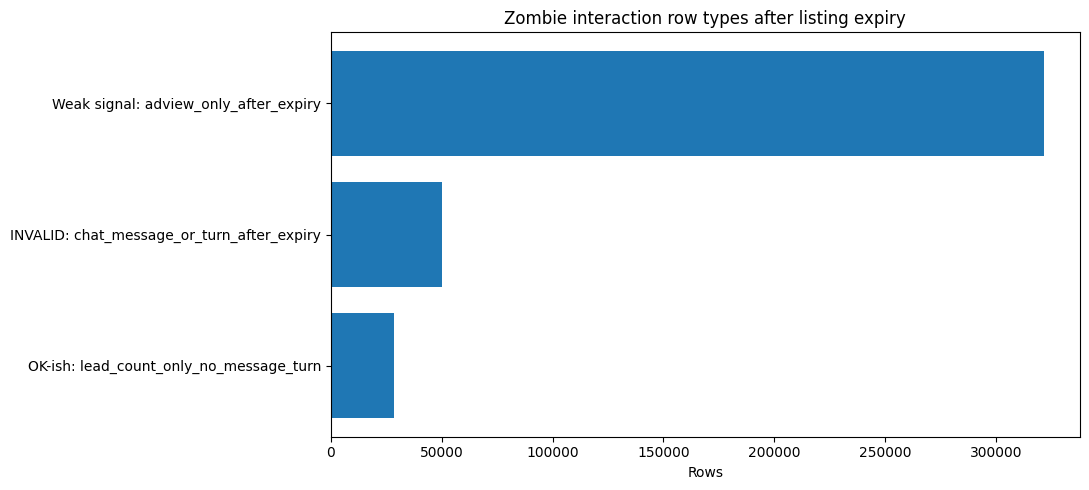

[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/plot_01_zombie_row_type_summary.png


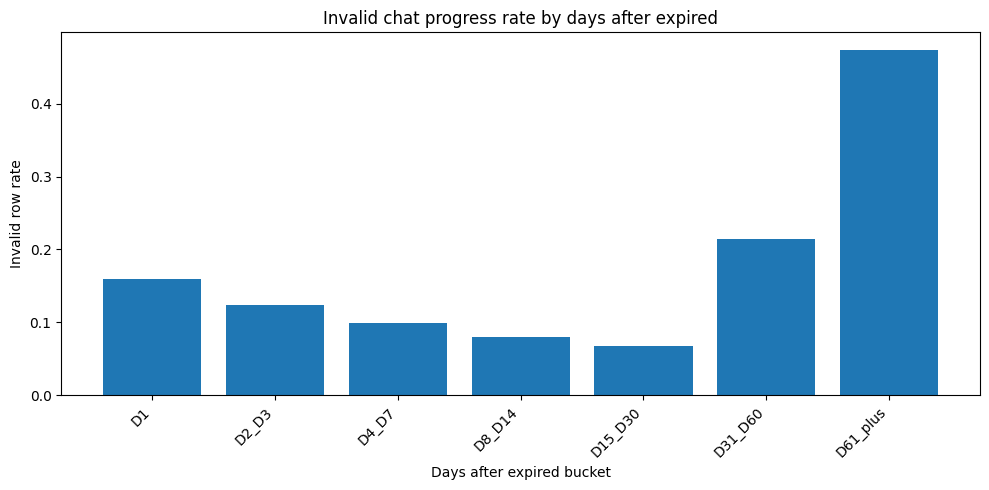

[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/plot_02_invalid_rate_by_days_after_expired_bucket.png


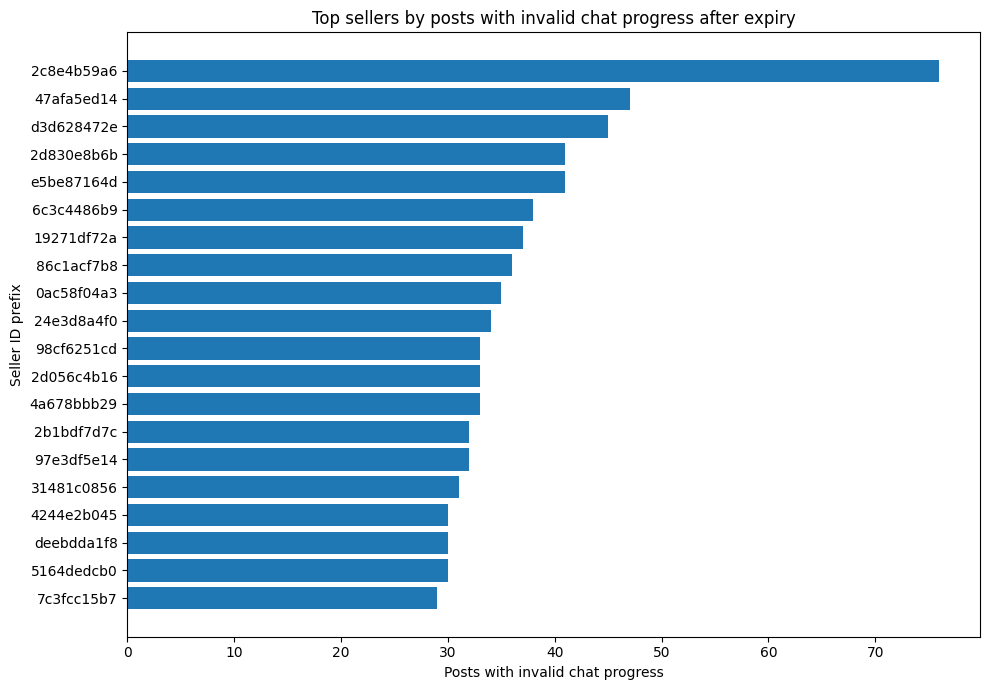

[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/plot_03_top_sellers_invalid_chat_progress_posts.png


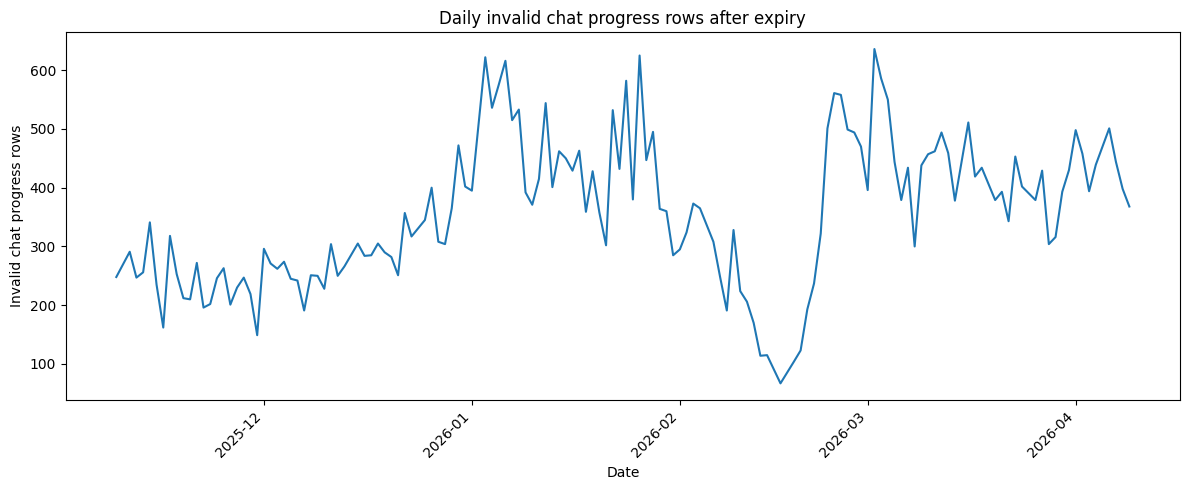

[SAVE] /kaggle/working/zombie_expired_chat_progress_audit/plot_04_daily_invalid_chat_progress_rows.png

DONE.
Output folder: /kaggle/working/zombie_expired_chat_progress_audit

File quan trọng nên xem:
04_overall_zombie_chat_progress_summary.csv
05_zombie_row_type_summary.csv
06_days_after_expired_bucket_summary.csv
07_zombie_item_chat_progress_summary.csv
08_zombie_seller_chat_progress_summary.csv
09_category_seller_type_chat_progress_summary.csv

Plot nên xem:
plot_01_zombie_row_type_summary.png
plot_02_invalid_rate_by_days_after_expired_bucket.png
plot_03_top_sellers_invalid_chat_progress_posts.png
plot_04_daily_invalid_chat_progress_rows.png


In [4]:
# ============================================================
# ZOMBIE EXPIRED CHAT PROGRESS AUDIT
#
# Goal:
# - Check fact_post_contact_interactions sau ngày hết hạn listing
# - Sau expiry có chat_lead/lead thì có thể còn chấp nhận được
# - Nhưng sau expiry KHÔNG nên còn chat_message_count > 0 hoặc chat_turn_count > 0
#
# Zombie logic:
#   interaction_date > expected_expired_date
#
# Output:
# /kaggle/working/zombie_expired_chat_progress_audit/
# ============================================================

import os
import sys
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. CONFIG
# ============================================================

BASE_PATH = "/kaggle/input/datasets/kimkhanhnguyen214/datathon2026-1"

DIM_LISTING_PATH = f"{BASE_PATH}/dim_listing"
INTERACTION_PATH = f"{BASE_PATH}/fact_post_contact_interactions"

OUTPUT_DIR = "/kaggle/working/zombie_expired_chat_progress_audit"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FORCE_REBUILD = True

DUCKDB_MEMORY_LIMIT = "4GB"
DUCKDB_THREADS = 4

# False: date > expected_expired_date
# True : date >= expected_expired_date
COUNT_EXPIRED_DATE_AS_ZOMBIE = False

print("DIM_LISTING_PATH exists:", os.path.exists(DIM_LISTING_PATH), DIM_LISTING_PATH)
print("INTERACTION_PATH exists:", os.path.exists(INTERACTION_PATH), INTERACTION_PATH)

# ============================================================
# 1. SETUP DUCKDB
# ============================================================

try:
    import duckdb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "duckdb"])
    import duckdb

duckdb_path = os.path.join(OUTPUT_DIR, "zombie_chat_progress_audit.duckdb")

if FORCE_REBUILD and os.path.exists(duckdb_path):
    os.remove(duckdb_path)

con = duckdb.connect(duckdb_path)
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")

DIM_GLOB = os.path.join(DIM_LISTING_PATH, "*.parquet").replace("\\", "/")
INTERACTION_GLOB = os.path.join(INTERACTION_PATH, "*.parquet").replace("\\", "/")

def save_csv(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("[SAVE]", path, "| shape:", df.shape)
    return path

def copy_parquet(query, out_path):
    out_path = out_path.replace("\\", "/")
    if FORCE_REBUILD and os.path.exists(out_path):
        os.remove(out_path)

    query = query.strip().rstrip(";")
    con.execute(f"""
        COPY (
            {query}
        )
        TO '{out_path}'
        (FORMAT PARQUET)
    """)

    print("[SAVE]", out_path)
    return out_path

# ============================================================
# 2. BUILD LIGHT dim_listing MAP
# ============================================================

dim_map_path = os.path.join(OUTPUT_DIR, "01_dim_listing_expiry_map.parquet")

dim_map_query = f"""
    SELECT
        CAST(item_id AS VARCHAR) AS item_id,
        CAST(seller_id AS VARCHAR) AS seller_id,

        TRY_CAST(category AS INTEGER) AS category,

        LOWER(TRIM(CAST(seller_type AS VARCHAR))) AS seller_type,
        LOWER(TRIM(CAST(ad_type AS VARCHAR))) AS ad_type,
        LOWER(TRIM(CAST(ad_status AS VARCHAR))) AS ad_status,

        CAST(posted_date AS DATE) AS posted_date,
        CAST(expected_expired_date AS DATE) AS expected_expired_date,

        CAST(city_name AS VARCHAR) AS city_name,
        CAST(district_name AS VARCHAR) AS district_name

    FROM read_parquet('{DIM_GLOB}')

    WHERE
        item_id IS NOT NULL
        AND expected_expired_date IS NOT NULL

    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY CAST(item_id AS VARCHAR)
        ORDER BY CAST(expected_expired_date AS DATE) DESC
    ) = 1
"""

copy_parquet(dim_map_query, dim_map_path)

dim_dq = con.execute(f"""
    SELECT
        COUNT(*) AS dim_items_with_expiry,
        COUNT(DISTINCT seller_id) AS sellers_with_expiry,
        MIN(posted_date) AS min_posted_date,
        MAX(posted_date) AS max_posted_date,
        MIN(expected_expired_date) AS min_expected_expired_date,
        MAX(expected_expired_date) AS max_expected_expired_date
    FROM read_parquet('{dim_map_path.replace("\\", "/")}')
""").df()

display(dim_dq)
save_csv(dim_dq, "01_dim_dq.csv")

# Seller total posts
seller_total_posts_path = os.path.join(OUTPUT_DIR, "02_seller_total_posts.parquet")

seller_total_posts_query = f"""
    SELECT
        seller_id,
        COUNT(DISTINCT item_id) AS seller_total_posts,
        ANY_VALUE(seller_type) AS seller_type_sample
    FROM read_parquet('{dim_map_path.replace("\\", "/")}')
    GROUP BY seller_id
"""

copy_parquet(seller_total_posts_query, seller_total_posts_path)

# ============================================================
# 3. BUILD ZOMBIE INTERACTION TABLE
# ============================================================

zombie_interaction_path = os.path.join(OUTPUT_DIR, "03_zombie_interaction_rows.parquet")

if COUNT_EXPIRED_DATE_AS_ZOMBIE:
    zombie_condition = "i.interaction_date >= d.expected_expired_date"
else:
    zombie_condition = "i.interaction_date > d.expected_expired_date"

zombie_interaction_query = f"""
    WITH inter AS (
        SELECT
            CAST(user_id AS VARCHAR) AS user_id,
            CAST(item_id AS VARCHAR) AS item_id,
            CAST(date AS DATE) AS interaction_date,

            COALESCE(TRY_CAST(adview_count AS DOUBLE), 0) AS adview_count,
            COALESCE(TRY_CAST(lead_count AS DOUBLE), 0) AS lead_count,
            COALESCE(TRY_CAST(chat_message_count AS DOUBLE), 0) AS chat_message_count,
            COALESCE(TRY_CAST(chat_turn_count AS DOUBLE), 0) AS chat_turn_count,
            COALESCE(TRY_CAST(chat_lead AS DOUBLE), 0) AS chat_lead,

            CASE
                WHEN LOWER(TRIM(CAST(purchased AS VARCHAR))) IN ('true', '1', 'yes', 'y', 't')
                THEN 1 ELSE 0
            END AS purchased_flag,

            TRY_CAST(category AS INTEGER) AS interaction_category

        FROM read_parquet('{INTERACTION_GLOB}')

        WHERE
            user_id IS NOT NULL
            AND item_id IS NOT NULL
            AND date IS NOT NULL
    ),

    joined AS (
        SELECT
            i.*,

            d.seller_id,
            d.category AS listing_category,
            d.seller_type,
            d.ad_type,
            d.ad_status,
            d.city_name,
            d.district_name,
            d.posted_date,
            d.expected_expired_date,

            DATE_DIFF('day', d.expected_expired_date, i.interaction_date) AS days_after_expired,

            CASE
                WHEN i.chat_lead > 0 THEN 1 ELSE 0
            END AS has_chat_lead,

            CASE
                WHEN i.lead_count > 0 THEN 1 ELSE 0
            END AS has_lead_count,

            CASE
                WHEN i.chat_message_count > 0 THEN 1 ELSE 0
            END AS has_chat_message_after_expiry,

            CASE
                WHEN i.chat_turn_count > 0 THEN 1 ELSE 0
            END AS has_chat_turn_after_expiry,

            CASE
                WHEN i.chat_message_count > 0 OR i.chat_turn_count > 0
                THEN 1 ELSE 0
            END AS has_invalid_chat_progress_after_expiry,

            CASE
                WHEN i.chat_lead > 0
                     AND i.chat_message_count = 0
                     AND i.chat_turn_count = 0
                THEN 1 ELSE 0
            END AS chat_lead_only_no_progress_after_expiry

        FROM inter i
        INNER JOIN read_parquet('{dim_map_path.replace("\\", "/")}') d
            ON i.item_id = d.item_id

        WHERE {zombie_condition}
    )

    SELECT *
    FROM joined
"""

copy_parquet(zombie_interaction_query, zombie_interaction_path)

# ============================================================
# 4. OVERALL SUMMARY
# ============================================================

overall_query = f"""
    SELECT
        COUNT(*) AS zombie_interaction_rows,

        COUNT(DISTINCT user_id) AS zombie_users,
        COUNT(DISTINCT item_id) AS zombie_items,
        COUNT(DISTINCT seller_id) AS zombie_sellers,

        SUM(adview_count) AS zombie_adviews,
        SUM(lead_count) AS zombie_leads,
        SUM(chat_lead) AS zombie_chat_leads,
        SUM(chat_message_count) AS zombie_chat_messages,
        SUM(chat_turn_count) AS zombie_chat_turns,

        SUM(has_chat_lead) AS rows_with_chat_lead,
        SUM(has_lead_count) AS rows_with_lead_count,

        SUM(has_chat_message_after_expiry) AS rows_with_chat_message_after_expiry,
        SUM(has_chat_turn_after_expiry) AS rows_with_chat_turn_after_expiry,
        SUM(has_invalid_chat_progress_after_expiry) AS rows_with_invalid_chat_progress_after_expiry,

        COUNT(DISTINCT CASE WHEN has_chat_lead = 1 THEN user_id END) AS users_with_chat_lead_after_expiry,
        COUNT(DISTINCT CASE WHEN has_chat_lead = 1 THEN item_id END) AS items_with_chat_lead_after_expiry,
        COUNT(DISTINCT CASE WHEN has_chat_lead = 1 THEN seller_id END) AS sellers_with_chat_lead_after_expiry,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN user_id END) AS users_with_invalid_chat_progress_after_expiry,
        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN item_id END) AS items_with_invalid_chat_progress_after_expiry,
        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN seller_id END) AS sellers_with_invalid_chat_progress_after_expiry,

        SUM(has_invalid_chat_progress_after_expiry) * 1.0 / NULLIF(COUNT(*), 0) AS invalid_chat_progress_row_rate,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN item_id END)
            * 1.0 / NULLIF(COUNT(DISTINCT item_id), 0) AS invalid_chat_progress_item_rate,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN seller_id END)
            * 1.0 / NULLIF(COUNT(DISTINCT seller_id), 0) AS invalid_chat_progress_seller_rate,

        MIN(interaction_date) AS first_zombie_interaction_date,
        MAX(interaction_date) AS last_zombie_interaction_date,

        MIN(days_after_expired) AS min_days_after_expired,
        AVG(days_after_expired) AS avg_days_after_expired,
        MAX(days_after_expired) AS max_days_after_expired

    FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')
"""

overall_df = con.execute(overall_query).df()
display(overall_df)
save_csv(overall_df, "04_overall_zombie_chat_progress_summary.csv")

# ============================================================
# 5. ROW TYPE SUMMARY
# ============================================================

row_type_query = f"""
    WITH z AS (
        SELECT
            *,
            CASE
                WHEN has_invalid_chat_progress_after_expiry = 1
                    THEN 'INVALID: chat_message_or_turn_after_expiry'

                WHEN chat_lead_only_no_progress_after_expiry = 1
                    THEN 'OK-ish: chat_lead_only_no_message_turn'

                WHEN has_lead_count = 1
                    THEN 'OK-ish: lead_count_only_no_message_turn'

                WHEN adview_count > 0
                    THEN 'Weak signal: adview_only_after_expiry'

                ELSE 'Other zombie row'
            END AS zombie_row_type
        FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')
    )

    SELECT
        zombie_row_type,

        COUNT(*) AS rows,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT item_id) AS items,
        COUNT(DISTINCT seller_id) AS sellers,

        SUM(adview_count) AS adviews,
        SUM(lead_count) AS leads,
        SUM(chat_lead) AS chat_leads,
        SUM(chat_message_count) AS chat_messages,
        SUM(chat_turn_count) AS chat_turns,

        COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () AS row_share,

        MIN(days_after_expired) AS min_days_after_expired,
        AVG(days_after_expired) AS avg_days_after_expired,
        MAX(days_after_expired) AS max_days_after_expired

    FROM z
    GROUP BY zombie_row_type
    ORDER BY rows DESC
"""

row_type_df = con.execute(row_type_query).df()
display(row_type_df)
save_csv(row_type_df, "05_zombie_row_type_summary.csv")

# ============================================================
# 6. DAYS AFTER EXPIRED BUCKET SUMMARY
# ============================================================

bucket_query = f"""
    WITH z AS (
        SELECT
            *,
            CASE
                WHEN days_after_expired = 0 THEN 'D0_same_expired_date'
                WHEN days_after_expired = 1 THEN 'D1'
                WHEN days_after_expired BETWEEN 2 AND 3 THEN 'D2_D3'
                WHEN days_after_expired BETWEEN 4 AND 7 THEN 'D4_D7'
                WHEN days_after_expired BETWEEN 8 AND 14 THEN 'D8_D14'
                WHEN days_after_expired BETWEEN 15 AND 30 THEN 'D15_D30'
                WHEN days_after_expired BETWEEN 31 AND 60 THEN 'D31_D60'
                ELSE 'D61_plus'
            END AS days_after_expired_bucket
        FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')
    )

    SELECT
        days_after_expired_bucket,

        COUNT(*) AS zombie_rows,
        COUNT(DISTINCT user_id) AS zombie_users,
        COUNT(DISTINCT item_id) AS zombie_items,
        COUNT(DISTINCT seller_id) AS zombie_sellers,

        SUM(has_chat_lead) AS rows_with_chat_lead,
        SUM(has_invalid_chat_progress_after_expiry) AS rows_with_invalid_chat_progress,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN user_id END) AS users_with_invalid_chat_progress,
        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN item_id END) AS items_with_invalid_chat_progress,
        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN seller_id END) AS sellers_with_invalid_chat_progress,

        SUM(chat_message_count) AS zombie_chat_messages,
        SUM(chat_turn_count) AS zombie_chat_turns,

        SUM(has_invalid_chat_progress_after_expiry) * 1.0 / NULLIF(COUNT(*), 0) AS invalid_row_rate

    FROM z
    GROUP BY days_after_expired_bucket
    ORDER BY
        CASE days_after_expired_bucket
            WHEN 'D0_same_expired_date' THEN 0
            WHEN 'D1' THEN 1
            WHEN 'D2_D3' THEN 2
            WHEN 'D4_D7' THEN 3
            WHEN 'D8_D14' THEN 4
            WHEN 'D15_D30' THEN 5
            WHEN 'D31_D60' THEN 6
            ELSE 7
        END
"""

bucket_df = con.execute(bucket_query).df()
display(bucket_df)
save_csv(bucket_df, "06_days_after_expired_bucket_summary.csv")

# ============================================================
# 7. ITEM SUMMARY
# ============================================================

item_summary_query = f"""
    SELECT
        item_id,
        seller_id,

        ANY_VALUE(listing_category) AS category,
        ANY_VALUE(seller_type) AS seller_type,
        ANY_VALUE(ad_type) AS ad_type,
        ANY_VALUE(ad_status) AS ad_status,
        ANY_VALUE(city_name) AS city_name,
        ANY_VALUE(district_name) AS district_name,

        MIN(posted_date) AS posted_date,
        MIN(expected_expired_date) AS expected_expired_date,

        COUNT(*) AS zombie_rows,
        COUNT(DISTINCT user_id) AS zombie_users,
        COUNT(DISTINCT interaction_date) AS zombie_days,

        SUM(adview_count) AS zombie_adviews,
        SUM(lead_count) AS zombie_leads,
        SUM(chat_lead) AS zombie_chat_leads,
        SUM(chat_message_count) AS zombie_chat_messages,
        SUM(chat_turn_count) AS zombie_chat_turns,

        SUM(has_chat_lead) AS rows_with_chat_lead,
        SUM(has_invalid_chat_progress_after_expiry) AS rows_with_invalid_chat_progress,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN user_id END) AS users_with_invalid_chat_progress,

        CASE
            WHEN SUM(has_invalid_chat_progress_after_expiry) > 0 THEN 1
            ELSE 0
        END AS item_has_invalid_chat_progress,

        MIN(interaction_date) AS first_zombie_interaction_date,
        MAX(interaction_date) AS last_zombie_interaction_date,

        MIN(CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN interaction_date END) AS first_invalid_chat_progress_date,
        MAX(CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN interaction_date END) AS last_invalid_chat_progress_date,

        MIN(days_after_expired) AS min_days_after_expired,
        AVG(days_after_expired) AS avg_days_after_expired,
        MAX(days_after_expired) AS max_days_after_expired

    FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')

    GROUP BY item_id, seller_id

    ORDER BY
        item_has_invalid_chat_progress DESC,
        zombie_chat_turns DESC,
        zombie_chat_messages DESC,
        zombie_rows DESC
"""

item_summary_df = con.execute(item_summary_query).df()
display(item_summary_df.head(50))
save_csv(item_summary_df, "07_zombie_item_chat_progress_summary.csv")

# ============================================================
# 8. SELLER SUMMARY
# ============================================================

seller_summary_query = f"""
    WITH item_level AS (
        SELECT
            seller_id,
            item_id,

            COUNT(*) AS zombie_rows,
            COUNT(DISTINCT user_id) AS zombie_users,

            SUM(has_chat_lead) AS rows_with_chat_lead,
            SUM(has_invalid_chat_progress_after_expiry) AS rows_with_invalid_chat_progress,

            SUM(chat_message_count) AS zombie_chat_messages,
            SUM(chat_turn_count) AS zombie_chat_turns,

            CASE
                WHEN SUM(has_chat_lead) > 0 THEN 1 ELSE 0
            END AS item_has_chat_lead_after_expiry,

            CASE
                WHEN SUM(has_invalid_chat_progress_after_expiry) > 0 THEN 1 ELSE 0
            END AS item_has_invalid_chat_progress_after_expiry,

            MIN(interaction_date) AS first_zombie_interaction_date,
            MAX(interaction_date) AS last_zombie_interaction_date,

            MIN(CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN interaction_date END) AS first_invalid_chat_progress_date,
            MAX(CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN interaction_date END) AS last_invalid_chat_progress_date,

            MAX(days_after_expired) AS max_days_after_expired

        FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')
        GROUP BY seller_id, item_id
    ),

    seller_zombie AS (
        SELECT
            seller_id,

            COUNT(DISTINCT item_id) AS zombie_posts,

            SUM(item_has_chat_lead_after_expiry) AS posts_with_chat_lead_after_expiry,
            SUM(item_has_invalid_chat_progress_after_expiry) AS posts_with_invalid_chat_progress_after_expiry,

            SUM(zombie_rows) AS zombie_rows,
            SUM(zombie_users) AS zombie_users_sum_by_item,

            SUM(rows_with_chat_lead) AS rows_with_chat_lead,
            SUM(rows_with_invalid_chat_progress) AS rows_with_invalid_chat_progress,

            SUM(zombie_chat_messages) AS zombie_chat_messages,
            SUM(zombie_chat_turns) AS zombie_chat_turns,

            MIN(first_zombie_interaction_date) AS first_zombie_interaction_date,
            MAX(last_zombie_interaction_date) AS last_zombie_interaction_date,

            MIN(first_invalid_chat_progress_date) AS first_invalid_chat_progress_date,
            MAX(last_invalid_chat_progress_date) AS last_invalid_chat_progress_date,

            MAX(max_days_after_expired) AS max_days_after_expired

        FROM item_level
        GROUP BY seller_id
    ),

    seller_total AS (
        SELECT *
        FROM read_parquet('{seller_total_posts_path.replace("\\", "/")}')
    )

    SELECT
        sz.seller_id,

        sz.zombie_posts,
        st.seller_total_posts,

        sz.posts_with_chat_lead_after_expiry,
        sz.posts_with_invalid_chat_progress_after_expiry,

        sz.zombie_posts * 1.0 / NULLIF(st.seller_total_posts, 0) AS zombie_post_rate,
        sz.posts_with_invalid_chat_progress_after_expiry * 1.0 / NULLIF(st.seller_total_posts, 0) AS invalid_chat_progress_post_rate_among_all_posts,
        sz.posts_with_invalid_chat_progress_after_expiry * 1.0 / NULLIF(sz.zombie_posts, 0) AS invalid_chat_progress_post_rate_among_zombie_posts,

        sz.zombie_rows,
        sz.zombie_users_sum_by_item,

        sz.rows_with_chat_lead,
        sz.rows_with_invalid_chat_progress,

        sz.rows_with_invalid_chat_progress * 1.0 / NULLIF(sz.zombie_rows, 0) AS invalid_chat_progress_row_rate,

        sz.zombie_chat_messages,
        sz.zombie_chat_turns,

        sz.first_zombie_interaction_date,
        sz.last_zombie_interaction_date,

        sz.first_invalid_chat_progress_date,
        sz.last_invalid_chat_progress_date,

        sz.max_days_after_expired,

        st.seller_type_sample

    FROM seller_zombie sz
    LEFT JOIN seller_total st
        ON sz.seller_id = st.seller_id

    ORDER BY
        sz.posts_with_invalid_chat_progress_after_expiry DESC,
        invalid_chat_progress_post_rate_among_all_posts DESC,
        sz.zombie_chat_turns DESC,
        sz.zombie_chat_messages DESC
"""

seller_summary_df = con.execute(seller_summary_query).df()
display(seller_summary_df.head(50))
save_csv(seller_summary_df, "08_zombie_seller_chat_progress_summary.csv")

# ============================================================
# 9. CATEGORY / SELLER TYPE SUMMARY
# ============================================================

category_summary_query = f"""
    SELECT
        listing_category AS category,
        seller_type,
        ad_type,

        COUNT(*) AS zombie_rows,
        COUNT(DISTINCT user_id) AS zombie_users,
        COUNT(DISTINCT item_id) AS zombie_items,
        COUNT(DISTINCT seller_id) AS zombie_sellers,

        SUM(has_chat_lead) AS rows_with_chat_lead,
        SUM(has_invalid_chat_progress_after_expiry) AS rows_with_invalid_chat_progress,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN item_id END) AS items_with_invalid_chat_progress,
        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN seller_id END) AS sellers_with_invalid_chat_progress,

        SUM(chat_message_count) AS zombie_chat_messages,
        SUM(chat_turn_count) AS zombie_chat_turns,

        SUM(has_invalid_chat_progress_after_expiry) * 1.0 / NULLIF(COUNT(*), 0) AS invalid_chat_progress_row_rate,

        COUNT(DISTINCT CASE WHEN has_invalid_chat_progress_after_expiry = 1 THEN item_id END)
            * 1.0 / NULLIF(COUNT(DISTINCT item_id), 0) AS invalid_chat_progress_item_rate

    FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')

    GROUP BY listing_category, seller_type, ad_type

    ORDER BY
        rows_with_invalid_chat_progress DESC,
        items_with_invalid_chat_progress DESC,
        zombie_rows DESC
"""

category_summary_df = con.execute(category_summary_query).df()
display(category_summary_df.head(50))
save_csv(category_summary_df, "09_category_seller_type_chat_progress_summary.csv")

# ============================================================
# 10. DAILY TREND
# ============================================================

daily_query = f"""
    SELECT
        interaction_date,

        COUNT(*) AS zombie_rows,
        COUNT(DISTINCT user_id) AS zombie_users,
        COUNT(DISTINCT item_id) AS zombie_items,
        COUNT(DISTINCT seller_id) AS zombie_sellers,

        SUM(has_chat_lead) AS rows_with_chat_lead,
        SUM(has_invalid_chat_progress_after_expiry) AS rows_with_invalid_chat_progress,

        SUM(chat_message_count) AS zombie_chat_messages,
        SUM(chat_turn_count) AS zombie_chat_turns,

        SUM(has_invalid_chat_progress_after_expiry) * 1.0 / NULLIF(COUNT(*), 0) AS invalid_chat_progress_row_rate

    FROM read_parquet('{zombie_interaction_path.replace("\\", "/")}')

    GROUP BY interaction_date
    ORDER BY interaction_date
"""

daily_df = con.execute(daily_query).df()
display(daily_df.head(50))
save_csv(daily_df, "10_daily_zombie_chat_progress_trend.csv")

# ============================================================
# 11. PLOTS
# ============================================================

# 11.1 Row type summary
if len(row_type_df) > 0:
    plot_df = row_type_df.sort_values("rows", ascending=True)

    plt.figure(figsize=(11, 5))
    plt.barh(plot_df["zombie_row_type"], plot_df["rows"])
    plt.title("Zombie interaction row types after listing expiry")
    plt.xlabel("Rows")
    plt.ylabel("")
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "plot_01_zombie_row_type_summary.png")
    plt.savefig(out_path, dpi=160)
    plt.show()
    print("[SAVE]", out_path)

# 11.2 Days bucket invalid rate
if len(bucket_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(bucket_df["days_after_expired_bucket"], bucket_df["invalid_row_rate"])
    plt.title("Invalid chat progress rate by days after expired")
    plt.xlabel("Days after expired bucket")
    plt.ylabel("Invalid row rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "plot_02_invalid_rate_by_days_after_expired_bucket.png")
    plt.savefig(out_path, dpi=160)
    plt.show()
    print("[SAVE]", out_path)

# 11.3 Top sellers by invalid posts
top_seller = seller_summary_df.head(20).copy()

if len(top_seller) > 0:
    top_seller["seller_short"] = top_seller["seller_id"].astype(str).str.slice(0, 10)

    plot_df = top_seller.sort_values("posts_with_invalid_chat_progress_after_expiry", ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["seller_short"], plot_df["posts_with_invalid_chat_progress_after_expiry"])
    plt.title("Top sellers by posts with invalid chat progress after expiry")
    plt.xlabel("Posts with invalid chat progress")
    plt.ylabel("Seller ID prefix")
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "plot_03_top_sellers_invalid_chat_progress_posts.png")
    plt.savefig(out_path, dpi=160)
    plt.show()
    print("[SAVE]", out_path)

# 11.4 Daily trend
if len(daily_df) > 0:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(daily_df["interaction_date"]), daily_df["rows_with_invalid_chat_progress"])
    plt.title("Daily invalid chat progress rows after expiry")
    plt.xlabel("Date")
    plt.ylabel("Invalid chat progress rows")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "plot_04_daily_invalid_chat_progress_rows.png")
    plt.savefig(out_path, dpi=160)
    plt.show()
    print("[SAVE]", out_path)

con.close()

print("\nDONE.")
print("Output folder:", OUTPUT_DIR)

print("\nFile quan trọng nên xem:")
print("04_overall_zombie_chat_progress_summary.csv")
print("05_zombie_row_type_summary.csv")
print("06_days_after_expired_bucket_summary.csv")
print("07_zombie_item_chat_progress_summary.csv")
print("08_zombie_seller_chat_progress_summary.csv")
print("09_category_seller_type_chat_progress_summary.csv")

print("\nPlot nên xem:")
print("plot_01_zombie_row_type_summary.png")
print("plot_02_invalid_rate_by_days_after_expired_bucket.png")
print("plot_03_top_sellers_invalid_chat_progress_posts.png")
print("plot_04_daily_invalid_chat_progress_rows.png")